100%|██████████| 5000/5000 [00:09<00:00, 537.63it/s]


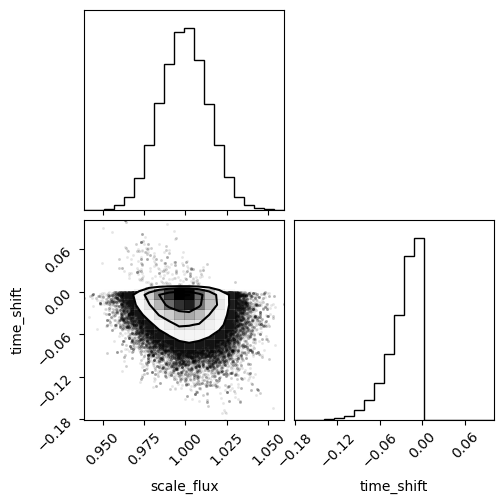

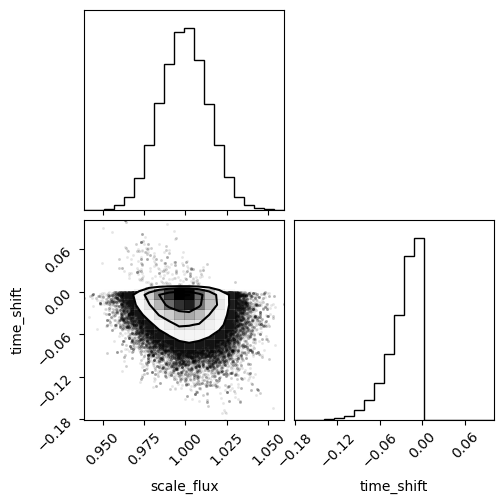

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import pickle
import emcee
import corner
from multiprocessing import Pool
from scipy.interpolate import interp1d

# --- Constants ---
M_sun = 2e33
M_tot = 0.01 * M_sun
c = 3e10
v_min = 0.1 * c
beta = 3
numshells = 10
sigma = 5.67e-5
h = 6.626e-27
nu = 1e14
D = 1e26
kB = 1.38e-16

# --- Time array ---
t = np.logspace(0, 6, 50)

# --- Shells ---
v_shells = np.linspace(0.1, 1, numshells) * c
M_shells = beta * M_tot * (v_min**(beta)) * (v_shells**(-beta-1))
M_shells = M_shells * M_tot / np.sum(M_shells)
E_int_shells = 0.5 * M_shells * (v_shells**2)

shell_data = pd.DataFrame({'Velocity (cm/s)': v_shells, 'Mass (g)': M_shells, 'Internal Energy (erg)': E_int_shells})

# --- Heating ---
av, bv, cv, xr = 0.56, 0.71, 0.74, 0.6
kv = [20, 5, 1]

def eps_th_v(t):
    t_day = t / 86400
    exp_term = np.exp(-av * t_day)
    log_term = np.log(1 + 2 * bv * t_day**cv)
    return 0.36 * (exp_term + (log_term / (2 * bv * t_day**cv)))

def e_dot_r(t):
    t0, sigma_t = 1.3, 0.11
    arctan_term = np.arctan((t - t0) / sigma_t)
    return 4e18 * eps_th_v(t) * (0.5 - (1 / np.pi) * arctan_term)**1.3

def Q_rv(Mv, t):
    return Mv * xr * e_dot_r(t)

def t_diff(M_shell, t):
    return ((M_shell**(4./3.)) * kv[2]) / (4 * np.pi * (M_tot**(1./3.)) * v_min * t * c)

def L_v(R, Eint, t_diff):
    t_lc = R / c
    return Eint / (t_diff + t_lc)

def energy(y, t, M):
    Eint, R, v = y
    diff_time = t_diff(M, t)
    dEint = -((Eint / R) * v) + Q_rv(M, t) - L_v(R, Eint, diff_time)
    dR = v
    dv = Eint / (M * R)
    return [dEint, dR, dv]

def pre_solve_shells(shell_data, t):
    E_all, R_all, v_all = [], [], []
    for i, row in shell_data.iterrows():
        M = row['Mass (g)']
        Eint0 = row['Internal Energy (erg)']
        v0 = row['Velocity (cm/s)']
        R0 = 1e9
        y0 = [Eint0, R0, v0]
        Edep = odeint(energy, y0, t, args=(M,))
        E_all.append(Edep[:, 0])
        R_all.append(Edep[:, 1])
        v_all.append(Edep[:, 2])
    return np.array(E_all), np.array(R_all), np.array(v_all)

def compute_photosphere_radius(R_all, shell_masses, t):
    num_shells, num_times = R_all.shape
    R_ph = np.zeros(num_times)
    tau_all = np.zeros_like(R_all)
    for i in range(num_shells):
        tau_all[i, :] = kv[2] * shell_masses[i] / (4 * np.pi * R_all[i, :]**2)
    tau_cumu = np.cumsum(tau_all[::-1], axis=0)[::-1]
    for i in range(num_times):
        tau_cumu_at_t = tau_cumu[:, i]
        if tau_cumu_at_t[-1] < 1:
            R_ph[i] = R_all[-1, i]
        else:
            idx = np.where(tau_cumu_at_t >= 1)[0][0]
            if idx == 0:
                R_ph[i] = R_all[0, i]
            else:
                tau_low = tau_cumu_at_t[idx - 1]
                tau_high = tau_cumu_at_t[idx]
                R_low = R_all[idx - 1, i]
                R_high = R_all[idx, i]
                f = (1 - tau_low) / (tau_high - tau_low)
                R_ph[i] = R_low + f * (R_high - R_low)
    return R_ph

def calculate_flux(R_ph, L_tot):
    T_eff = (L_tot / (4 * np.pi * sigma * R_ph**2))**(1/4)
    Flux = ((2 * np.pi * h * nu**3) / (c**2)) * (1 / (np.exp((h * nu) / (kB * T_eff)) - 1)) * (R_ph**2 / D**2)
    return Flux

# --- Precompute everything ---
E_all, R_all, v_all = pre_solve_shells(shell_data, t)
R_ph = compute_photosphere_radius(R_all, M_shells, t)
L_tot = np.sum([L_v(R, Eint, t_diff(shell_data['Mass (g)'][i], t)) 
                for i, (R, Eint) in enumerate(zip(R_all, E_all))], axis=0)
Flux_ref = calculate_flux(R_ph, L_tot)

# --- Create synthetic data ---
noise_level = 0.1
Flux_values = Flux_ref
Flux_perturbed = Flux_values + noise_level * Flux_values * np.random.randn(*Flux_values.shape)
noise = noise_level * Flux_values

# --- MCMC functions ---
def model(theta, t):
    scale_flux, time_shift = theta
    t_shifted = t + time_shift
    t_shifted[t_shifted <= 0] = 1e-10
    flux_interp = interp1d(t, Flux_ref, bounds_error=False, fill_value=0.0)
    return scale_flux * flux_interp(t_shifted)

def log_prior(theta):
    scale_flux, time_shift = theta
    if 0.1 < scale_flux < 10.0 and -5e5 < time_shift < 5e5:
        return 0.0
    return -np.inf

def log_posterior(theta, t, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp - 0.5 * np.sum(((y - model(theta, t)) / yerr)**2)

ndim = 2
nwalkers = 32
nsteps = 5000
p0 = np.array([1.0, 0.0]) + 1e-2 * np.random.randn(nwalkers, ndim)

# No Pool: directly initialize the sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(t, Flux_perturbed, noise))
sampler.run_mcmc(p0, nsteps, progress=True)

# --- Analyze ---
samples = sampler.get_chain(flat=True)
corner.corner(samples, labels=["scale_flux", "time_shift"])

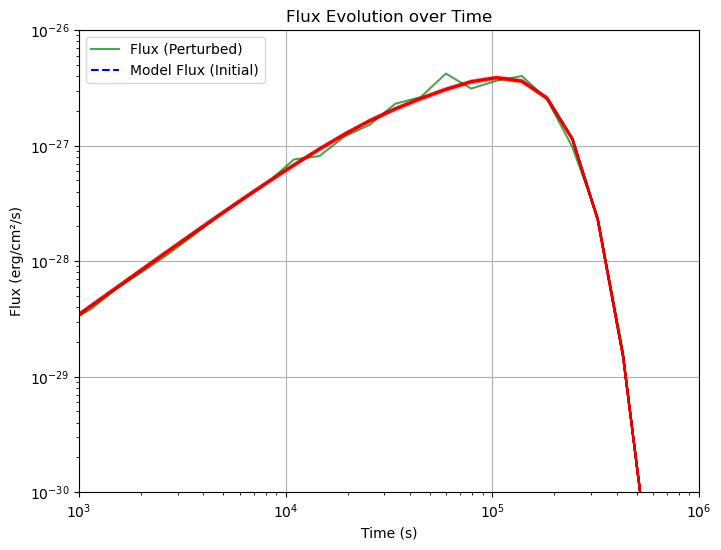

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Set initial theta for plotting (initial guess)
theta_initial = [1.0, 0.0]

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the total flux (sum of all shells) with noise added (Flux_perturbed)
plt.loglog(t, Flux_perturbed, label='Flux (Perturbed)', color='green', alpha=0.7)

# Plot the model flux using the initial parameters
plt.loglog(t, model(theta_initial, t), label='Model Flux (Initial)', color='blue', linestyle='--')

# Plot the model flux for a range of random samples from the MCMC chain
for theta in samples[np.random.randint(len(samples), size=100)]:
    plt.plot(t, model(theta, t), color="red", alpha=0.05)

# Add labels and title
plt.xlabel('Time (s)')
plt.ylabel('Flux (erg/cm²/s)')
plt.xlim([1e3, 1e6])  # avoid zero on log-log plot
plt.ylim([1e-30, 1e-26])
plt.title('Flux Evolution over Time')

# Display grid and legend
plt.grid(True)
plt.legend()

# Show the plot
plt.show()
